# Taller 5:  Filtros lineales y no lineales

In [1]:
PATH = './imagenes/'

## Cargue la imagen meb.png y remuestréela para obtener una imagen de tamaño 2048x2048.

Cargamos y visualizamos la imagen original.

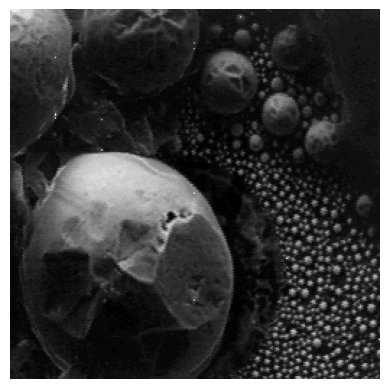

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread(PATH + 'MEB.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen, cmap='gray')
plt.axis('off')
plt.show()

Completamos el remuestreo con `cv2.resize` y visualizamos la imagen resultante. Luego validamos las dimensiones de la nueva imagen.

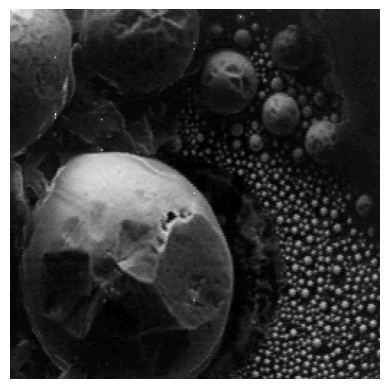

In [3]:
imagen_remuestreada = cv2.resize(imagen, (2048, 2048), interpolation=cv2.INTER_NEAREST)
plt.imshow(imagen_remuestreada, cmap='gray')
plt.axis('off')
plt.show()

In [5]:
print('Dimensiones de la imagen original:', imagen.shape)
print('Dimensiones de la imagen remuestreada:', imagen_remuestreada.shape)

Dimensiones de la imagen original: (256, 256)
Dimensiones de la imagen remuestreada: (2048, 2048)


## Aplique un filtros promedio de 3x3 a la imagen usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

Construimos una función que ejecuta un filtro por convolución el número de veces especificado por `num_ejecuciones`, registra los tiempos de cada ejecución y calcula automáticamente estadísticas (promedio, mínimo, máximo y desviación estándar).

In [ ]:
from scipy.ndimage import convolve
import time
def aplicar_filtro_y_medir_tiempo(imagen, kernel, num_ejecuciones=50):
    """
    Aplica un filtro a una imagen varias veces y mide los tiempos de ejecución.
    
    Args:
        imagen: imagen sobre la que aplicar el filtro
        kernel: kernel de convolución
        num_ejecuciones: número de veces a ejecutar el filtro
    
    Returns:
        imagen_filtrada: imagen después de aplicar el filtro
        tiempos: lista con los tiempos de cada ejecución
        estadisticas: diccionario con promedio, mín y máx
    """
    tiempos = []
    
    print(f"\nKernel: {kernel.shape}")
    print("-" * 50)
    
    for i in range(num_ejecuciones):
        tiempo_inicio = time.time()
        imagen_filtrada = convolve(imagen, kernel, mode='constant', cval=0)
        tiempo_fin = time.time()
        
        tiempo_ejecucion = tiempo_fin - tiempo_inicio
        tiempos.append(tiempo_ejecucion)
        print(f"Ejecución {i+1}: {tiempo_ejecucion:.6f} segundos")
    
    estadisticas = {
        'promedio': np.mean(tiempos),
        'minimo': np.min(tiempos),
        'maximo': np.max(tiempos),
        'desv_est': np.std(tiempos)
    }
    
    print(f"\nTiempo promedio: {estadisticas['promedio']:.6f} segundos")
    print(f"Tiempo mínimo: {estadisticas['minimo']:.6f} segundos")
    print(f"Tiempo máximo: {estadisticas['maximo']:.6f} segundos")
    print(f"Desviación estándar: {estadisticas['desv_est']:.6f} segundos")
    
    return imagen_filtrada, tiempos, estadisticas

Aplicamos 50 veces el filtro promedio 3x3 y guardamos el tiempo de las corridas.

In [ ]:
kernel_3x3 = np.array([[1, 1, 1],
                       [1, 1, 1],
                       [1, 1, 1]]) / 9
imagen_filtrada_3x3, tiempos_3x3, estadisticas_3x3 = aplicar_filtro_y_medir_tiempo(imagen_remuestreada, kernel_3x3)


Kernel: (3, 3)
--------------------------------------------------
Ejecución 1: 0.055660 segundos
Ejecución 2: 0.050877 segundos
Ejecución 3: 0.048264 segundos
Ejecución 4: 0.048738 segundos
Ejecución 5: 0.052701 segundos
Ejecución 6: 0.049199 segundos
Ejecución 7: 0.048244 segundos
Ejecución 8: 0.048948 segundos
Ejecución 9: 0.052705 segundos
Ejecución 10: 0.049134 segundos
Ejecución 11: 0.049877 segundos
Ejecución 12: 0.049384 segundos
Ejecución 13: 0.048961 segundos
Ejecución 14: 0.054548 segundos
Ejecución 15: 0.050236 segundos
Ejecución 16: 0.048083 segundos
Ejecución 17: 0.050367 segundos
Ejecución 18: 0.048555 segundos
Ejecución 19: 0.050509 segundos
Ejecución 20: 0.049415 segundos
Ejecución 21: 0.048311 segundos
Ejecución 22: 0.048628 segundos
Ejecución 23: 0.048217 segundos
Ejecución 24: 0.050370 segundos
Ejecución 25: 0.048206 segundos
Ejecución 26: 0.048273 segundos
Ejecución 27: 0.049444 segundos
Ejecución 28: 0.048788 segundos
Ejecución 29: 0.049664 segundos
Ejecución 30: 

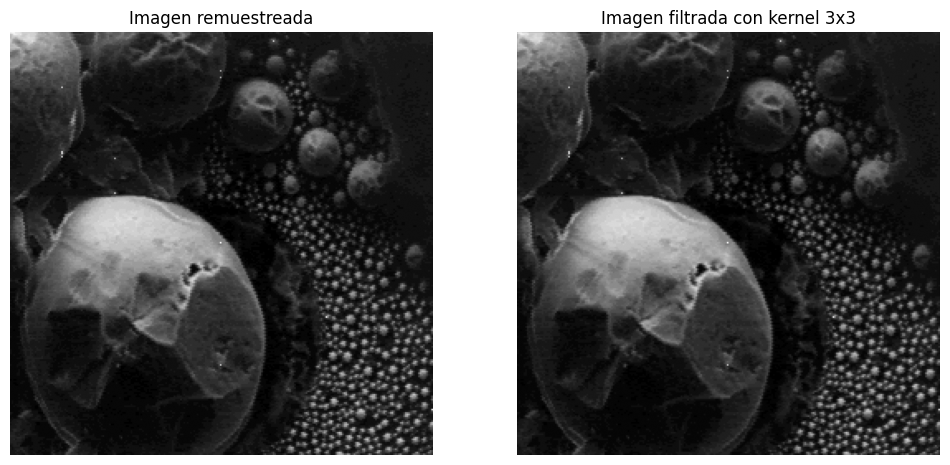

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(imagen_remuestreada, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Imagen remuestreada')
ax[1].imshow(imagen_filtrada_3x3, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Imagen filtrada con kernel 3x3')
plt.show()


## Aplique un filtro promedio de 3x1 sobre la imagen de trabajo y luego un filtro promedio de 1x3 usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

Aplicamos el filtro 3x1 y luego el filtro 1x3 de forma secuencial. Creamos una función que nos permite medir el tiempo de ejecución de un número variable de iteraciones.


Pipeline separable optimizado: (3, 1) + (1, 3)
--------------------------------------------------
Ejecución 1: 0.109583 segundos
Ejecución 2: 0.046218 segundos
Ejecución 3: 0.043213 segundos
Ejecución 4: 0.050039 segundos
Ejecución 5: 0.042287 segundos
Ejecución 6: 0.043771 segundos
Ejecución 7: 0.046505 segundos
Ejecución 8: 0.043720 segundos
Ejecución 9: 0.043356 segundos
Ejecución 10: 0.047779 segundos
Ejecución 11: 0.042287 segundos
Ejecución 12: 0.042699 segundos
Ejecución 13: 0.046363 segundos
Ejecución 14: 0.043509 segundos
Ejecución 15: 0.042690 segundos
Ejecución 16: 0.047790 segundos
Ejecución 17: 0.041847 segundos
Ejecución 18: 0.043195 segundos
Ejecución 19: 0.048774 segundos
Ejecución 20: 0.042287 segundos
Ejecución 21: 0.042990 segundos
Ejecución 22: 0.047615 segundos
Ejecución 23: 0.043032 segundos
Ejecución 24: 0.042896 segundos
Ejecución 25: 0.048097 segundos
Ejecución 26: 0.043046 segundos
Ejecución 27: 0.041660 segundos
Ejecución 28: 0.046057 segundos
Ejecución 29: 

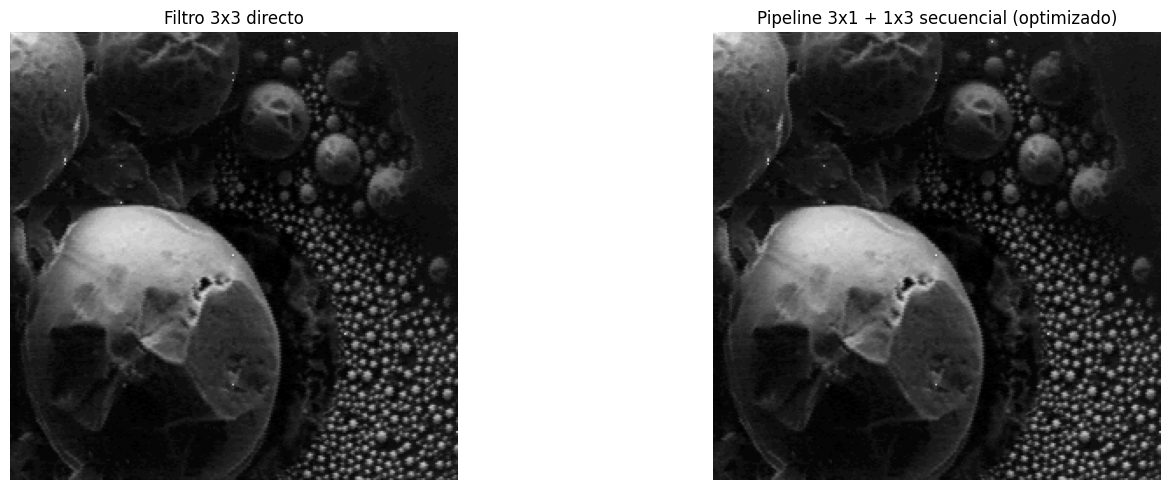

In [31]:
from scipy.ndimage import convolve1d

def aplicar_pipeline_separable(imagen, kernel_3x1, kernel_1x3, num_ejecuciones=50):
    """
    Aplica un pipeline de dos filtros secuenciales (3x1 + 1x3) y mide el tiempo total.
    Utiliza convolve1d, que está optimizado para filtros unidimensionales.
    
    Args:
        imagen (ndarray): Imagen de entrada sobre la que aplicar el pipeline de filtros.
        kernel_3x1 (ndarray): Kernel de convolución vertical de forma (3, 1).
        kernel_1x3 (ndarray): Kernel de convolución horizontal de forma (1, 3).
        num_ejecuciones (int, optional): Número de iteraciones para medir tiempos. 
                                         Por defecto es 50.
    
    Returns:
        tuple: Una tupla con tres elementos:
            - imagen_filtrada (ndarray): Imagen resultante después de aplicar ambos filtros.
            - tiempos (list): Lista con los tiempos de ejecución (en segundos) de cada iteración.
            - estadisticas (dict): Diccionario con estadísticas de los tiempos.
    """
    tiempos = []
    
    # Aplanar los kernels a 1D
    kernel_vertical = kernel_3x1.flatten()
    kernel_horizontal = kernel_1x3.flatten()
    
    print(f"\nPipeline separable optimizado: {kernel_3x1.shape} + {kernel_1x3.shape}")
    print("-" * 50)
    
    for i in range(num_ejecuciones):
        tiempo_inicio = time.time()
        # Primera pasada: convolución vertical (axis=0, filas)
        temp = convolve1d(imagen, kernel_vertical, axis=0, mode='reflect', cval=0)
        # Segunda pasada: convolución horizontal (axis=1, columnas)
        imagen_filtrada = convolve1d(temp, kernel_horizontal, axis=1, mode='reflect', cval=0)
        tiempo_fin = time.time()
        
        tiempo_ejecucion = tiempo_fin - tiempo_inicio
        tiempos.append(tiempo_ejecucion)
        print(f"Ejecución {i+1}: {tiempo_ejecucion:.6f} segundos")
    
    estadisticas = {
        'promedio': np.mean(tiempos),
        'minimo': np.min(tiempos),
        'maximo': np.max(tiempos),
        'desv_est': np.std(tiempos)
    }
    
    print(f"\nTiempo promedio: {estadisticas['promedio']:.6f} segundos")
    print(f"Tiempo mínimo: {estadisticas['minimo']:.6f} segundos")
    print(f"Tiempo máximo: {estadisticas['maximo']:.6f} segundos")
    print(f"Desviación estándar: {estadisticas['desv_est']:.6f} segundos")
    
    return imagen_filtrada, tiempos, estadisticas

# Aplicar pipeline optimizado
kernel_3x1 = np.array([[1], [1], [1]]) / 3
kernel_1x3 = np.array([[1, 1, 1]]) / 3

imagen_filtrada_separable, tiempos_pipeline, estadisticas_pipeline = aplicar_pipeline_separable(
    imagen_remuestreada, kernel_3x1, kernel_1x3
)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].imshow(imagen_filtrada_3x3, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Filtro 3x3 directo')

ax[1].imshow(imagen_filtrada_separable, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Pipeline 3x1 + 1x3 secuencial (optimizado)')

plt.tight_layout()
plt.show()

## Grafique el resultado comparativo de los tiempos de ejecución para los puntos anteriores.

Construimos un gráfico boxplot junto a un gráfico de barras para comparar los tiempos de ejecución del filtro 3x3 directo versus el pipeline separable 3x1 + 1x3. El boxplot nos permite visualizar la distribución de los tiempos junto a sus percentiles 25, 50 y 75, además de los outliers y variabilidad. El gráfico de barras compara los tiempos promedio de ambos métodos en las 50 ejecuciones realizadas.

/tmp/ipykernel_1279/2897786460.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(datos_tiempos, labels=nombres_filtros, patch_artist=True, showmeans=True)


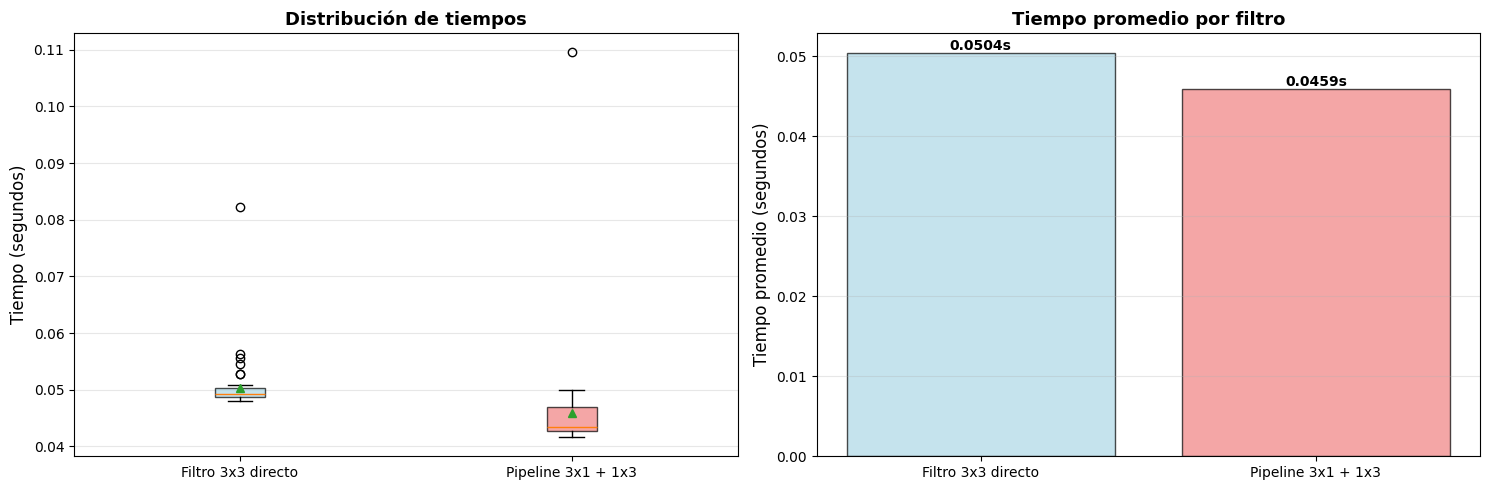

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

datos_tiempos = [tiempos_3x3, tiempos_pipeline]
nombres_filtros = ['Filtro 3x3 directo', 'Pipeline 3x1 + 1x3']

bp = ax1.boxplot(datos_tiempos, labels=nombres_filtros, patch_artist=True, showmeans=True)
colores = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Tiempo (segundos)', fontsize=12)
ax1.set_title('Distribución de tiempos', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

tiempos_promedio = [estadisticas_3x3['promedio'], estadisticas_pipeline['promedio']]
barras = ax2.bar(nombres_filtros, tiempos_promedio, color=colores, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Tiempo promedio (segundos)', fontsize=12)
ax2.set_title('Tiempo promedio por filtro', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for barra, tiempo in zip(barras, tiempos_promedio):
    altura = barra.get_height()
    ax2.text(barra.get_x() + barra.get_width()/2., altura,
             f'{tiempo:.4f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Podemos ver cómo el pipeline de 3x1 + 1x3 es más rápido que el filtro de 3x3 promedio.

## Efectúe una sustracción de estas imágenes para corroborar el resultado Las dos imágenes resultantes, ¿son idénticas? 

In [33]:
# Verificar si el kernel 3x1 + 1x3 es realmente equivalente al 3x3
kernel_separable = np.outer(kernel_3x1.flatten(), kernel_1x3.flatten())
print("Kernel 3x1 ⊗ 1x3:\n", kernel_separable)
print("\nKernel 3x3:\n", kernel_3x3)
print("\n¿Son iguales?", np.allclose(kernel_separable, kernel_3x3))

Kernel 3x1 ⊗ 1x3:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Kernel 3x3:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

¿Son iguales? True


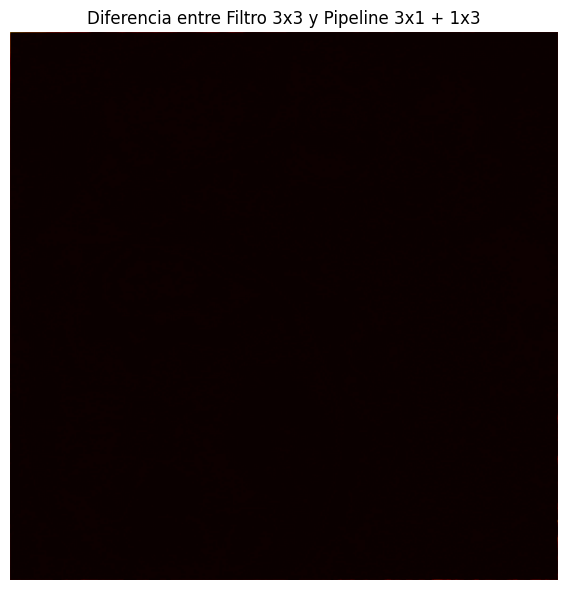

In [35]:
diferencia = imagen_filtrada_3x3.astype(float) - imagen_filtrada_separable.astype(float)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(np.abs(diferencia), cmap='hot')
ax.set_title('Diferencia entre Filtro 3x3 y Pipeline 3x1 + 1x3')
ax.axis('off')
plt.tight_layout()
plt.show()

Con la visualización de la diferencia es evidente que las imágenes de filtro promedio 3x3 y la del pipeline de 3x1 + 1x3 son idénticas.

## Revise la siguiente explicación en separabilidad de filtros lineales. Explique la diferencia de los tiempos de ejecución determinando el número de operaciones elementales (SUMA, RESTA) efectuadas por las dos versiones del filtro. 

Calcule la duración de ejecución que se debería obtener con un filtro promedio 10 veces más grande (es decir de tamaño 30x30). Verifique este resultado experimentalmente e intente explicar el tiempo de cálculo observado (pensando en los métodos de optimización utilizables con el filtro promedio separable).